# Verifying one-dimensional heat conduction
### A manufactured solution, mesh refinement, and an energy check

This notebook solves steady conduction in a slab and checks whether the numerical error decreases at second order as the mesh is refined. The inputs are synthetic educational data.

**Targets:** observed orders between 1.9 and 2.1 for both refinement pairs, and an energy imbalance below 1% on the finest mesh.

Run the cells from top to bottom with a Python kernel containing NumPy, Matplotlib, and IPython. All solver code is included here.

**Notation:** `T` is always the **numerical solution**. `T_exact` is the **analytic reference** evaluated at the same nodes. Their difference is the numerical error.

## 1. Governing equation and manufactured solution

For a constant-area slab with constant conductivity, no advection, and no radiation,

$$-k\frac{d^2T}{dx^2}=q(x),\qquad 0<x<L,$$
$$L=0.10\ \mathrm{m},\qquad k=10\ \mathrm{W\,m^{-1}\,K^{-1}},\qquad T(0)=T(L)=300\ \mathrm{K}.$$

Choose the analytic temperature first, then derive the source that makes it an exact solution:

$$T^*(x)=T_b+A_T\sin\left(\frac{\pi x}{L}\right),\qquad T_b=300\ \mathrm{K},\quad A_T=10\ \mathrm{K},$$
$$\frac{d^2T^*}{dx^2}=-A_T\left(\frac{\pi}{L}\right)^2\sin\left(\frac{\pi x}{L}\right),$$
$$\boxed{q(x)=kA_T\left(\frac{\pi}{L}\right)^2\sin\left(\frac{\pi x}{L}\right)}.$$

The source has units $\mathrm{W\,m^{-3}}$. It is evaluated from this continuous expression, independently of the numerical stencil. That independence is essential: using the same discrete stencil to manufacture the source could conceal discretization error.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

L = 0.10
k = 10.0
T0 = T1 = 300.0
amplitude = 10.0
meshes = [10, 20, 40]

plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

def exact_temperature(x):
    return T0 + amplitude * np.sin(np.pi * x / L)

def source_term(x):
    return k * amplitude * (np.pi / L)**2 * np.sin(np.pi * x / L)

## 2. Discretization and boundary conditions

Use $N$ equal intervals, $N+1$ nodes, and spacing $h=L/N$. At an interior node,

$$T''(x_i)=\frac{T_{i-1}-2T_i+T_{i+1}}{h^2}+\mathcal{O}(h^2).$$

Thus the linear system uses

$$-\frac{k}{h^2}T_{i-1}+\frac{2k}{h^2}T_i-\frac{k}{h^2}T_{i+1}=q(x_i).$$

Only interior temperatures are unknown. Known endpoint values move to the right-hand side:

$$b_1=q(x_1)+\frac{kT_0}{h^2},\qquad b_{N-1}=q(x_{N-1})+\frac{kT_N}{h^2}.$$

The matrix already contains $h^{-2}$, so the source must **not** be divided by $h^2$ again. Add boundary contributions after filling the source vector so they cannot be overwritten.

In [2]:
def solve_temperature(N):
    h = L / N
    x = np.linspace(0, L, N + 1)
    A = (k / h**2) * (2 * np.eye(N - 1)
                       - np.eye(N - 1, k=1) - np.eye(N - 1, k=-1))
    b = source_term(x[1:-1]).copy()
    b[0] += k * T0 / h**2
    b[-1] += k * T1 / h**2
    T = np.empty(N + 1)
    T[0], T[-1] = T0, T1
    T[1:-1] = np.linalg.solve(A, b)
    return x, T

## 3. Error, observed order, and energy balance

The maximum nodal error is

$$E(N)=\max_i|T_i-T^*(x_i)|.$$

If $E\approx Ch^p$, halving $h$ gives

$$\boxed{p=\frac{\ln[E(N)/E(2N)]}{\ln 2}}.$$

Each error uses a **different numerical solve**. Comparing `EN_value` with `EN(T, T_exact)` on the same mesh compares an error with itself and gives zero order.

### Flux signs and exact heat generation

Define heat flux in the positive $x$ direction by $j=-kT'$. The outward normals are $-1$ on the left and $+1$ on the right, so total outward heat flux per unit area is $j(L)-j(0)$.

$$Q_A=\int_0^Lq(x)\,dx=\frac{2kA_T\pi}{L}\approx6283.1853\ \mathrm{W\,m^{-2}}.$$

For the exact solution, $j(0)=-kA_T\pi/L$ and $j(L)=+kA_T\pi/L$. Estimate numerical endpoint derivatives with second-order one-sided formulas:

$$T'(0)\approx\frac{-3T_0+4T_1-T_2}{2h},\qquad
T'(L)\approx\frac{3T_N-4T_{N-1}+T_{N-2}}{2h}.$$

The relative imbalance is

$$\boxed{\epsilon_Q=\frac{|j_h(L)-j_h(0)-Q_A|}{|Q_A|}}.$$

The source must be subtracted: a ratio of outward flux to generation approaches one, while an imbalance approaches zero. We use the analytic integral to avoid adding quadrature error to this check.

In [3]:
def boundary_fluxes(T, h):
    left = -k * (-3*T[0] + 4*T[1] - T[2]) / (2*h)
    right = -k * (3*T[-1] - 4*T[-2] + T[-3]) / (2*h)
    return left, right

integrated_q = 2 * k * amplitude * np.pi / L
results = []
for N in meshes:
    x, T = solve_temperature(N)
    T_exact = exact_temperature(x)
    left, right = boundary_fluxes(T, L / N)
    results.append(dict(N=N, h=L/N, x=x, T=T, T_exact=T_exact,
                        error=np.max(np.abs(T - T_exact)), order=None,
                        imbalance=abs(right - left - integrated_q) / integrated_q))

for coarse, fine in zip(results[:-1], results[1:]):
    coarse['order'] = np.log(coarse['error'] / fine['error']) / np.log(coarse['h'] / fine['h'])

table = ['| Intervals | Spacing (m) | Max error (K) | Order to next mesh | Imbalance (%) |',
         '|---:|---:|---:|---:|---:|']
for r in results:
    order = '—' if r['order'] is None else f"{r['order']:.4f}"
    table.append(f"| {r['N']} | {r['h']:.4f} | {r['error']:.6f} | {order} | {100*r['imbalance']:.6f} |")
display(Markdown('\n'.join(table)))

| Intervals | Spacing (m) | Max error (K) | Order to next mesh | Imbalance (%) |
|---:|---:|---:|---:|---:|
| 10 | 0.0100 | 0.082654 | 2.0053 | 4.030204 |
| 20 | 0.0050 | 0.020587 | 2.0013 | 1.022932 |
| 40 | 0.0025 | 0.005142 | — | 0.256699 |

## 4. Temperature and local error

The temperature curves nearly overlap. The separate error panel makes their differences visible; the error is plotted as solved minus exact temperature.

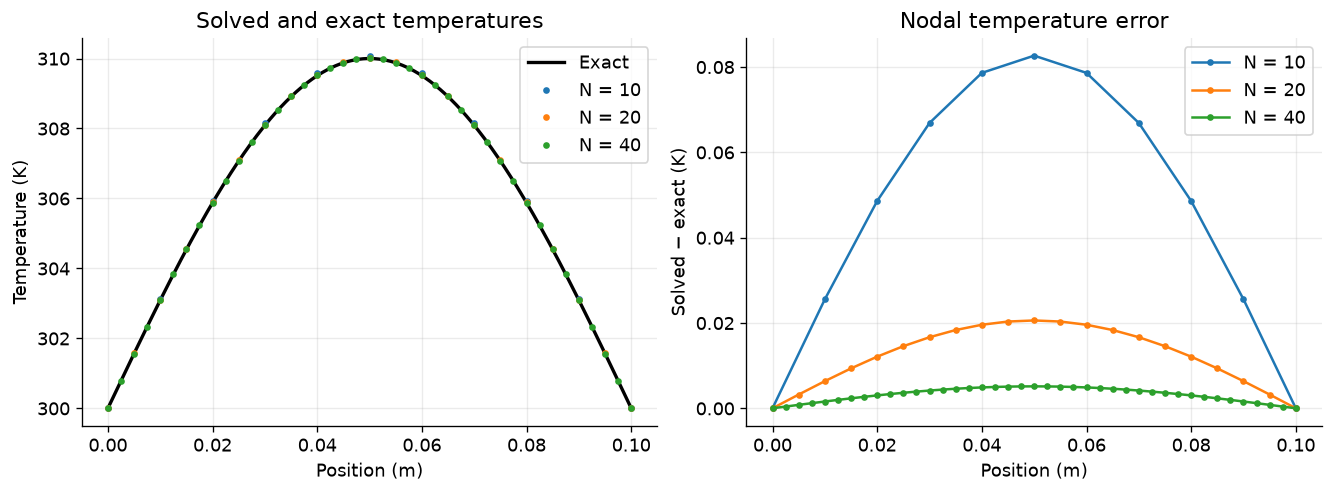

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')
xf = np.linspace(0, L, 401)
axes[0].plot(xf, exact_temperature(xf), color='black', lw=2, label='Exact')
for r in results:
    axes[0].plot(r['x'], r['T'], 'o', ms=3, label=f"N = {r['N']}")
    axes[1].plot(r['x'], r['T'] - r['T_exact'], 'o-', ms=3, label=f"N = {r['N']}")
axes[0].set(xlabel='Position (m)', ylabel='Temperature (K)', title='Solved and exact temperatures')
axes[1].set(xlabel='Position (m)', ylabel='Solved − exact (K)', title='Nodal temperature error')
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()
plt.show()

## 5. Mesh convergence

For a second-order method, doubling the number of intervals should reduce error by about four. The dashed reference below is anchored to the coarsest temperature error and follows $N^{-2}$. The energy panel uses a separate scale because it measures a different quantity.

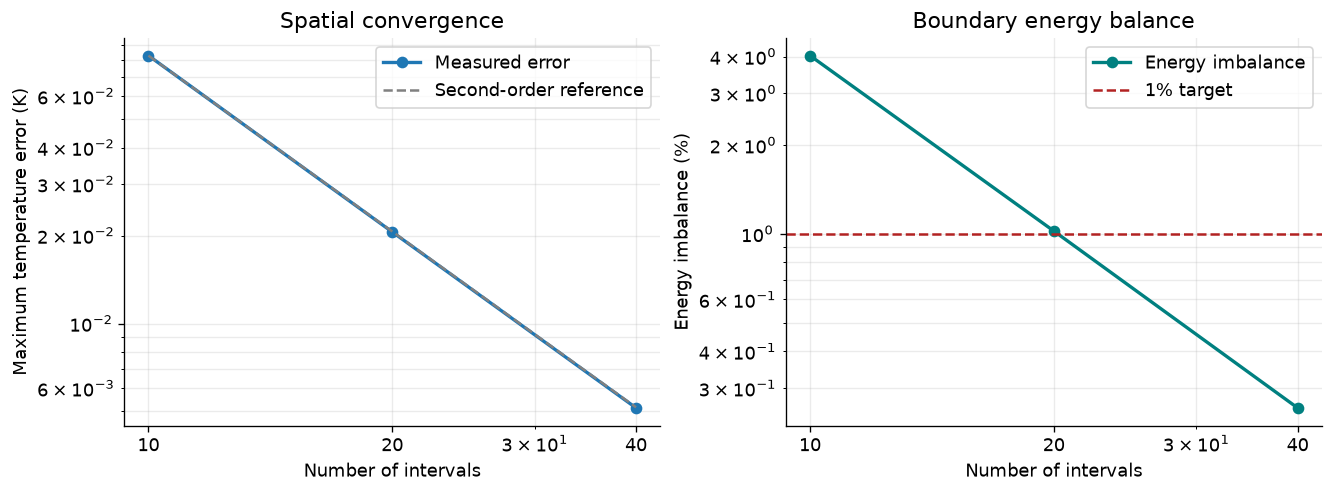

In [5]:
counts = np.array(meshes)
errors = np.array([r['error'] for r in results])
imbalances = 100 * np.array([r['imbalance'] for r in results])
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')
axes[0].loglog(counts, errors, 'o-', lw=2, label='Measured error')
axes[0].loglog(counts, errors[0]*(counts[0]/counts)**2, '--', color='gray', label='Second-order reference')
axes[0].set(ylabel='Maximum temperature error (K)', title='Spatial convergence')
axes[1].loglog(counts, imbalances, 'o-', lw=2, color='teal', label='Energy imbalance')
axes[1].axhline(1, color='firebrick', ls='--', label='1% target')
axes[1].set(ylabel='Energy imbalance (%)', title='Boundary energy balance')
for ax in axes:
    ax.set_xlabel('Number of intervals')
    ax.set_xticks(counts, labels=[str(n) for n in counts])
    ax.grid(alpha=0.25, which='both')
    ax.legend()
plt.show()

## 6. Automatic checks

These checks enforce the stated targets and basic properties of this symmetric manufactured problem.

In [6]:
assert all(1.9 <= r['order'] <= 2.1 for r in results[:-1])
assert results[-1]['imbalance'] < 0.01
for r in results:
    T = r['T']
    assert T[0] == T0 and T[-1] == T1
    np.testing.assert_allclose(T, T[::-1], rtol=0, atol=1e-9)
    assert np.argmax(T) == r['N'] // 2
print('PASS: convergence orders, finest-mesh energy balance, boundaries, symmetry, and center maximum.')

PASS: convergence orders, finest-mesh energy balance, boundaries, symmetry, and center maximum.


## 7. Discussion of results

For the default parameters:

- **Second-order behavior is observed.** The maximum errors are approximately 0.082654, 0.020587, and 0.005142 K. Each refinement reduces error by about four; the observed orders of 2.0053 and 2.0013 meet the 1.9–2.1 target.
- **The finest mesh meets the energy target.** Imbalance decreases from 4.0302% to 1.0229% to 0.2567%. The 20-interval mesh narrowly misses the 1% target, while the 40-interval mesh passes. Boundary flux reconstruction still has discretization error even when the linear system is solved accurately.
- **The temperature profile has the expected shape.** Both boundaries are 300 K, the solution is symmetric, and its maximum occurs at the slab center. The numerical solution slightly overpredicts the analytic 310 K peak, with the difference decreasing under refinement.
- **No order is reported on the final row.** An additional 80-interval solve would be needed to calculate the order from 40 to 80 intervals.

### Why a small matrix residual is insufficient

The algebraic residual $\mathbf{r}=\mathbf{A}\mathbf{T}_{\mathrm{int}}-\mathbf{b}$ measures how well the discrete equations were solved. A very small residual can occur even with an incorrect source, missing boundary contributions, or substantial discretization error. Comparison with the independent analytic solution and mesh refinement checks whether those discrete equations approximate the intended differential equation.

### Scope of the conclusion

This exercise supports spatial verification for a smooth, one-dimensional, constant-conductivity problem on uniform meshes. It does not establish accuracy for variable conductivity, complex geometry, nonlinear boundary conditions, or experimental data. Agreement with measured physical behavior would require a separate validation study.

### Try next

Add 80 to `meshes` and rerun all cells. Predict the temperature error and energy imbalance before running: second-order behavior suggests roughly one-quarter of their 40-interval values. The discussion above records the default three-mesh run; the table and plots update when the inputs change.